# Probability

Probability is a way of **quantifying uncertainty** associated with events chosen from some universe of events.

### Key Terms
- **Universe** — all possible outcomes (e.g. rolling a die: $\{1, 2, 3, 4, 5, 6\}$)
- **Event** — any subset of outcomes (e.g. "rolls a 1" or "rolls an even number")
- **Notation** — $P(E)$ means "the probability of event $E$"

### Why It Matters for Data Science
- Building models
- Evaluating models
- Quantifying uncertainty everywhere

## Dependence and Independence

Two events $E$ and $F$ are **dependent** if knowing whether $E$ happens gives us information about whether $F$ happens. Otherwise, they are **independent**.

### Examples

- **Independent:** Flipping a fair coin twice — knowing the first flip is heads gives no information about the second flip.
- **Dependent:** Knowing the first flip is heads tells us the two flips cannot both be tails. These events are dependent.

### Mathematical Definition

Two events $E$ and $F$ are independent if:

$$P(E, F) = P(E)P(F)$$

**Coin flip example:**
- $P(\text{first flip heads}) = \frac{1}{2}$
- $P(\text{both flips tails}) = \frac{1}{4}$
- $P(\text{first flip heads and both flips tails}) = 0$

Since $0 \neq \frac{1}{2} \cdot \frac{1}{4}$, these two events are **dependent**.

## Conditional Probability

### Definition

When two events $E$ and $F$ are **independent**:

$$P(E, F) = P(E)P(F)$$

When they are **not necessarily independent**, the probability of $E$ conditional on $F$ is:

$$P(E \mid F) = \frac{P(E, F)}{P(F)}$$

Think of this as: *the probability that $E$ happens, given that we know $F$ happens.* We can rewrite this as:

$$P(E, F) = P(E \mid F)P(F)$$

When $E$ and $F$ are independent, this reduces to:

$$P(E \mid F) = P(E)$$

meaning knowing $F$ gives us no additional information about $E$.

### Example — Family with Two Children

Assume each child is equally likely to be a boy or girl, and the genders are independent. The possible outcomes are:

| Outcome | Probability |
|---------|-------------|
| Two boys | $\frac{1}{4}$ |
| One girl, one boy | $\frac{1}{2}$ |
| Two girls | $\frac{1}{4}$ |

### Case 1: "Both girls" given "older child is a girl"

Let $B$ = both children are girls, $G$ = older child is a girl.

$$P(B \mid G) = \frac{P(B, G)}{P(G)} = \frac{P(B)}{P(G)} = \frac{1/4}{1/2} = \frac{1}{2}$$

Since knowing both are girls implies the older is a girl, $P(B, G) = P(B)$.

### Case 2: "Both girls" given "at least one is a girl"

Let $L$ = at least one child is a girl.

$$P(B \mid L) = \frac{P(B, L)}{P(L)} = \frac{P(B)}{P(L)} = \frac{1/4}{3/4} = \frac{1}{3}$$

**Why is this different?** Knowing at least one child is a girl rules out "two boys" but leaves three equally likely outcomes: (girl, boy), (boy, girl), (girl, girl). Only one of those three is "both girls" — so the probability is $\frac{1}{3}$, not $\frac{1}{2}$.

We can check this by "generating" a lot of families:


In [48]:
import enum, random

# An enum is a typed set of enumerated values. We can use them 
# to make our code more descriptive and readable. 

class Kid(enum.Enum):
    BOY = 0 
    GIRL = 1
def random_kid() -> Kid:
    return random.choice([Kid.BOY, Kid.GIRL])

both_girls  = 0
older_girl  = 0
either_girl = 0

random.seed(0)

for _ in range(10000):
    younger = random_kid()
    older   = random_kid()
    
    if older == Kid.GIRL:
        older_girl += 1
    if older == Kid.GIRL and younger == Kid.GIRL:
        both_girls += 1
    if older == Kid.GIRL or younger == Kid.GIRL:
        either_girl += 1
        
print("P(both | older):", both_girls / older_girl) 
print("P(both | either): ", both_girls / either_girl)

P(both | older): 0.5007089325501317
P(both | either):  0.3311897106109325


## Bayes's Theorem

Bayes's theorem is a way of **reversing conditional probabilities** — computing $P(E \mid F)$ when we only know $P(F \mid E)$.

### Derivation

Starting from the definition of conditional probability:

$$P(E \mid F) = \frac{P(E, F)}{P(F)} = \frac{P(F \mid E)P(E)}{P(F)}$$

Since $F$ can be split into two mutually exclusive events — "$F$ and $E$" and "$F$ and $\neg E$":

$$P(F) = P(F, E) + P(F, \neg E)$$

Substituting gives the full statement of Bayes's theorem:

$$P(E \mid F) = \frac{P(F \mid E)P(E)}{P(F \mid E)P(E) + P(F \mid \neg E)P(\neg E)}$$


### Example — Disease Testing

A disease affects 1 in 10,000 people. A test is 99% accurate. What is the probability you actually have the disease given a positive test?

Let $T$ = "test is positive", $D$ = "you have the disease":

$$P(D \mid T) = \frac{P(T \mid D)P(D)}{P(T \mid D)P(D) + P(T \mid \neg D)P(\neg D)}$$

| Term | Meaning | Value |
|------|---------|-------|
| $P(T \mid D)$ | Probability of positive test given disease | $0.99$ |
| $P(D)$ | Probability of having the disease | $0.0001$ |
| $P(T \mid \neg D)$ | Probability of positive test without disease | $0.01$ |
| $P(\neg D)$ | Probability of not having the disease | $0.9999$ |

Substituting:

$$P(D \mid T) = \frac{(0.99)(0.0001)}{(0.99)(0.0001) + (0.01)(0.9999)} \approx 0.0098$$

**Less than 1% of people who test positive actually have the disease.**

### Intuition — 1 Million People

| Group | Count |
|-------|-------|
| Have disease | 100 |
| Have disease and test positive | 99 |
| Don't have disease | 999,900 |
| Don't have disease but test positive | 9,999 |

Out of $99 + 9{,}999 = 10{,}098$ positive tests, only **99** are true positives.

> **Note:** This assumes people are tested at random. If only symptomatic people are tested, $P(D)$ is much higher and the result changes significantly.

## Random Variables

A **random variable** is a variable whose possible values have an associated probability distribution.

### Examples

| Random Variable | Possible Values | Distribution |
|----------------|-----------------|--------------|
| Coin flip | $0$ or $1$ | $P(0) = 0.5,\ P(1) = 0.5$ |
| Heads in 10 flips | $0$ to $10$ | Binomial |
| `range(10)` pick | $0$ to $9$ | $P(x) = 0.1$ each |

### Expected Value

The **expected value** is the average of a variable's values weighted by their probabilities:

$$E[X] = \sum_x x \cdot P(X = x)$$

- Coin flip: $E[X] = 0 \cdot \frac{1}{2} + 1 \cdot \frac{1}{2} = \frac{1}{2}$
- `range(10)`: $E[X] = 4.5$

### Conditioning Random Variables

From the two-child example, let $X$ = number of girls:

| Variable | Condition | $P = 1$ | $P = 2$ |
|----------|-----------|---------|---------|
| $X$ | None | $\frac{1}{2}$ | $\frac{1}{4}$ |
| $Y$ | At least one girl | $\frac{2}{3}$ | $\frac{1}{3}$ |
| $Z$ | Older child is a girl | $\frac{1}{2}$ | $\frac{1}{2}$ |

---

## Continuous Distributions

A **discrete distribution** assigns positive probability to discrete outcomes (e.g. a coin flip). A **continuous distribution** models outcomes across a continuum of real numbers.

### Probability Density Function (PDF)

Because there are infinitely many values in any interval, individual points have probability zero. Instead, we represent continuous distributions with a **PDF** $f(x)$, where:

$$P(a \leq X \leq b) = \int_a^b f(x)\, dx$$

**Intuition:** for small $h$, the probability of seeing a value between $x$ and $x + h$ is approximately:

$$P(x \leq X \leq x + h) \approx h \cdot f(x)$$

### Uniform Distribution

The **uniform distribution** puts equal weight on all numbers in $[0, 1]$:

$$f(x) = \begin{cases} 1 & \text{if } 0 \leq x \leq 1 \\ 0 & \text{otherwise} \end{cases}$$

In [49]:
def uniform_pdf(x: float) -> float:
    return 1 if 0 <= x < 1 else 0

The probability that a random variable following that distribution is between 0.2 and 0.3 is 1/10. Python's ```random.random``` is a (pseudo)random variable with a uniform density. 

We will often be more interested in the *cumulative distribution function* (CDF), which gives the probability that a random variable is less than or equal to a certin value. It's not hard to create the CDF for the uniform distribution:

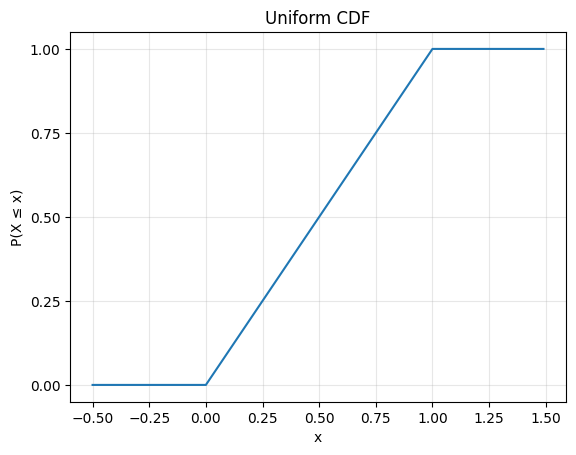

In [50]:
def uniform_cdf(x:float )->float:
    """Returns the probability that a uniform random variable is <=x"""
    if x < 0:   return 0 # uniform random is never less than 0
    elif x < 1: return x # P(X <= 0.4) = 0.4
    else:       return 1 # uniform random is always less than 1a
    
import matplotlib.pyplot as plt
import numpy as np

xs = [x / 100 for x in range(-50, 150)]  # -0.5 to 1.5
ys = [uniform_cdf(x) for x in xs]

plt.plot(xs, ys)
plt.title("Uniform CDF")
plt.xlabel("x")
plt.ylabel("P(X ≤ x)")
plt.yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.grid(True, alpha=0.3)
plt.show()

## The Normal Distribution

The **normal distribution** is the classic bell curve, fully determined by two parameters:

- $\mu$ (mu) — the **mean**, indicating where the bell is centered
- $\sigma$ (sigma) — the **standard deviation**, indicating how "wide" it is

### Probability Density Function

$$f(x \mid \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

We can implement this as:


In [51]:
import numpy as np
import math

SQRT_TWO_PI = np.sqrt(2 * math.pi)

def normal_pdf(x:float, mu:float = 0, sigma:float =1) -> float:
    return (np.exp(-(x-mu) ** 2 / 2 / sigma ** 2)/ (SQRT_TWO_PI * sigma))

Plot the PDFs to see what they look like:

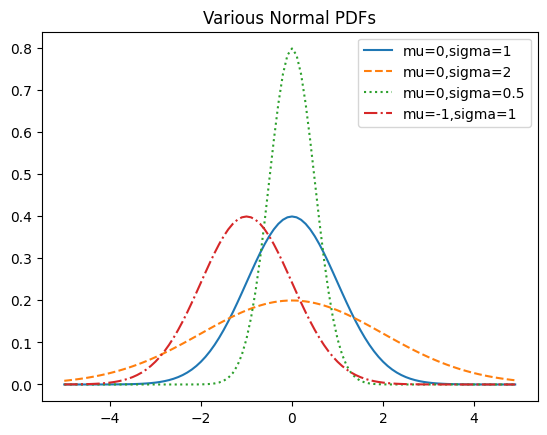

In [52]:
import matplotlib.pyplot as plt 

xs = [x / 10.0 for x in range(-50, 50)]
plt.plot(xs,[normal_pdf(x,sigma=1) for x in xs],'-',label='mu=0,sigma=1')
plt.plot(xs,[normal_pdf(x,sigma=2) for x in xs],'--',label='mu=0,sigma=2')
plt.plot(xs,[normal_pdf(x,sigma=0.5) for x in xs],':',label='mu=0,sigma=0.5')
plt.plot(xs,[normal_pdf(x,mu=-1) for x in xs],'-.',label='mu=-1,sigma=1')
plt.legend()
plt.title("Various Normal PDFs")
plt.show()

When $\mu = 0$ and $\sigma = 1$, it's called the *standard normal deviation*. If $Z$ is a standard normal random variable, then it turns out that:

$$X = \sigma Z + \mu$$

is also normal but with mean $\mu$ and standard deviation $\sigma$. Conversely, if $X$ is a normal random variable with mean $\mu$ and standard deviation $\sigma$, 

$$Z = \frac{(X-\mu)}{\sigma}$$

is a standard normal variable. 

The CDF for the normal distribution cannot be writte in an "elementary" manner, we can write it using ```math.erf``` function:

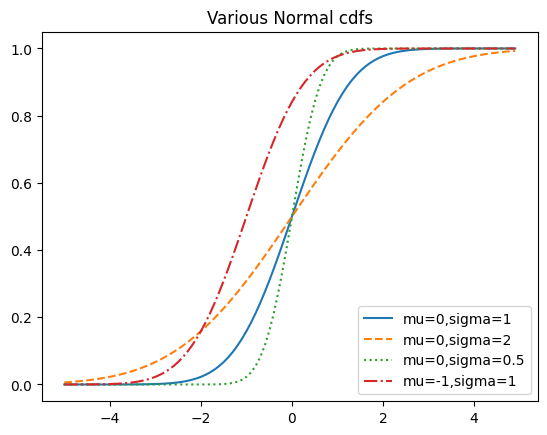

In [53]:
def normal_cdf(x: float, mu:float = 0, sigma:float=1) -> float:
    return (1 + math.erf((x-mu)/math.sqrt(2) / sigma)) /2


# Plotting a few CDFs
xs = [x / 10.0 for x in range(-50, 50)]
plt.plot(xs,[normal_cdf(x,sigma=1) for x in xs],'-',label='mu=0,sigma=1')
plt.plot(xs,[normal_cdf(x,sigma=2) for x in xs],'--',label='mu=0,sigma=2')
plt.plot(xs,[normal_cdf(x,sigma=0.5) for x in xs],':',label='mu=0,sigma=0.5')
plt.plot(xs,[normal_cdf(x,mu=-1) for x in xs],'-.',label='mu=-1,sigma=1')
plt.legend(loc=4) # bottom right
plt.title("Various Normal cdfs")
plt.show()

Sometimes we'll need to invert ```normal_cdf``` to find the value corresponding to a specified probability. There's no simple way to compute its inverse, but ```normal_cdf``` is continous and strictly increasing, so we can use a *binary search*

In [54]:
def inverse_normal_cdf( p: float,
                        mu:float = 0,
                        sigma:float = 1,
                        tolerance:float = 0.00001)->float:
    """Find the approximate inverse using binary search"""
    # if not standard, compute and rescale
    if mu!=0 or sigma != 1:
        return mu + sigma * inverse_normal_cdf(p, mu=0, sigma=1, tolerance=tolerance)
    
    # binary search
    lo_z = -10.0 # normal_cdf(-10) is very close to 0
    hi_z = 10.0  # normal_cdf(10) is very close to 1
    
    while hi_z - lo_z > tolerance:
        mid_z = (lo_z + hi_z) / 2   # consider the midpoint
        mid_p = normal_cdf(mid_z)   # and the CDF's value there
        if mid_p < p:
            lo_z = mid_z           # Midpoint too low, search ABOVE it
        else: 
            hi_z = mid_z            # Midpoint too high, search BELOW it
            
    return mid_z

This function repeatedly bisects the intervals until it narrows it on a $Z$ that's close enough to the desired probability.

## The Central Limit Theorem

The **central limit theorem (CLT)** states that the average of a large number of independent and identically distributed (i.i.d.) random variables is itself approximately normally distributed — regardless of the underlying distribution.

### Formal Statement

If $x_1, \ldots, x_n$ are i.i.d. random variables with mean $\mu$ and standard deviation $\sigma$, then for large $n$:

$$x_1 + \cdots + x_n \sim \mathcal{N}(\mu n,\ \sigma\sqrt{n})$$

Equivalently, the standardized version:

$$\frac{(x_1 + \cdots + x_n) - \mu n}{\sigma \sqrt{n}} \sim \mathcal{N}(0, 1)$$

### Illustration — Binomial Random Variables

A $\text{Binomial}(n, p)$ random variable is the sum of $n$ independent $\text{Bernoulli}(p)$ variables, each equal to $1$ with probability $p$ and $0$ with probability $1 - p$:

$$\mu = p \qquad \sigma = \sqrt{p(1-p)}$$

As $n$ grows large, the binomial distribution converges to a normal distribution by the CLT.


In [55]:
def bernoulli_trial(p:float) -> int:
    """Returns 1 with probability p and 0 with probability 1 - p"""
    return 1 if random.random() < p else 0

def binomial(n: int, p: float) -> int:
    """Returns the sum of n bernoulli(p) trials"""
    return sum(bernoulli_trial(p) for _ in range(n))

### Binomial Approximation to Normal

For a $\text{Binomial}(n, p)$ variable, the CLT gives us:

$$\mu = np \qquad \sigma = \sqrt{np(1-p)}$$

As $n$ grows large, the binomial histogram increasingly resembles a normal bell curve.



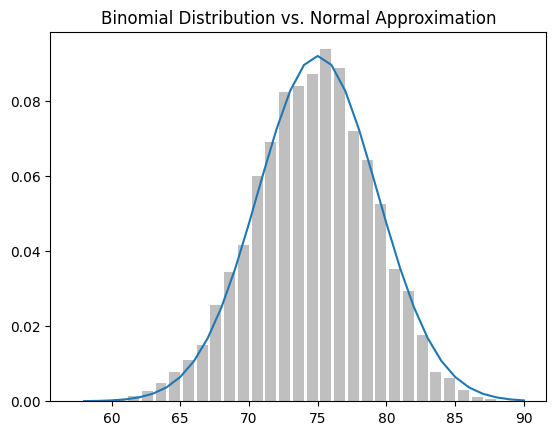

In [57]:
from collections import Counter

def binomial_histogram(p:float, n:int, num_points:int) -> None:
    """Picks points from a Binomial(n, p) and plots their histogram"""
    data = [binomial(n,p) for _ in range(num_points)]
    
    # use a bar chart to show the actual binomial samples
    histogram = Counter(data)
    plt.bar([x - 0.4 for x in histogram.keys()],
            [v / num_points for v in histogram.values()], 
             0.8, 
             color = '0.75')
    
    mu = p * n
    sigma = math.sqrt(n * p * (1 - p))
    
    # use a line chart to show the normal approximation
    xs = range(min(data), max(data) + 1)
    ys = [normal_cdf(i + 0.5, mu, sigma) - normal_cdf(i - 0.5, mu, sigma) for i in xs]
    plt.plot(xs, ys)
    plt.title("Binomial Distribution vs. Normal Approximation")
    plt.show()
    
    
binomial_histogram(0.75, 100, 10000)

The moral of this approximation is that if you want to know the probability that (say) a fair coin turns up more than 60 heads in 100 flips, you can estimate it as the probability that a Normal(50,5) is greater than 60, which is easier than computing the Binomial(100, 5) CDF.

```scipy.stat``` contains PDF and CDF functions for most of the popular probability distributions